# 06 — Model Comparison

**Day:** 6 of the project plan
**Goal:** stop training, start comparing. Pull every per-model metrics JSON
and predictions npz that Days 3-5 saved, and produce a single summary view.

This notebook produces:

1. A side-by-side metrics table (accuracy, macro precision/recall/F1, weighted F1, epochs, runtime).
2. Three confusion matrices in one figure for visual comparison.
3. A grouped bar chart of headline metrics.
4. A grouped bar chart of per-class F1.
5. A short observations block — which model is best, where the confusions are, and how to interpret them given the dataset's known limitations.

> **Limitation reminder.** The dataset is augmented and upsampled. Image-level
> splitting can leak near-duplicates → all numbers below are *upper bounds* on
> a clinical evaluation. We compare architectures on equal footing, not the
> models' clinical fitness.


## 0. Environment setup

In [1]:
import os, sys
from pathlib import Path

def _find_project_root():
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Could not find src/config.py.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import google.colab; IN_COLAB = True
    from google.colab import drive; drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False
print("In Colab:", IN_COLAB)


In Colab: False


In [2]:
from src.config import summary, FIGURES_DIR, REPORTS_DIR, PREDICTIONS_DIR
from src.comparison import (
    load_all_metrics, comparison_table, per_class_f1_table,
    plot_confusion_matrices_side_by_side, plot_per_class_f1_bars,
    plot_headline_metrics_bars, write_comparison_report,
)
print(summary())


Environment: local
Project root: C:\Users\miaot\Github\Project_DeepLearningClass
Data root:    C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images
Outputs:      C:\Users\miaot\Github\Project_DeepLearningClass\outputs
Classes:      ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Image size:   128x128x3
Seed:         42



## 1. Load every model's persisted metrics

We just read the JSON / npz files that Days 3-5 wrote — there is no retraining here. If you re-run a model on Colab, just rerun this notebook to refresh the comparison.

In [3]:
metrics = load_all_metrics()
print("Loaded metrics for:", list(metrics.keys()))


Loaded metrics for: ['baseline_cnn', 'mobilenetv2', 'vgg16']


## 2. Headline metrics table

In [4]:
table_df = comparison_table(metrics)
table_df


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,epochs_run,elapsed_seconds,n_test
0,baseline_cnn,0.9053,0.9104,0.9080,0.9084,0.9047,30,11652.21,6601
1,mobilenetv2,0.7426,0.7511,0.7467,0.7430,0.7375,20,6680.10,6601
2,vgg16,0.7290,0.7391,0.7332,0.7348,0.7287,15,4258.22,6601


## 3. Per-class F1

Macro F1 hides which class is hard. Plan flags VeryMildDemented vs MildDemented as the most-likely confusable pair.

In [5]:
per_class_f1_table(metrics).round(4)


model,baseline_cnn,mobilenetv2,vgg16
class,,,
MildDemented,0.9354,0.7277,0.7170
ModerateDemented,0.9909,0.9560,0.9472
NonDemented,0.8870,0.7404,0.7138
VeryMildDemented,0.8204,0.5478,0.5611


## 4. Headline-metric bar chart

Saved: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\06_metrics_grouped_bars.png


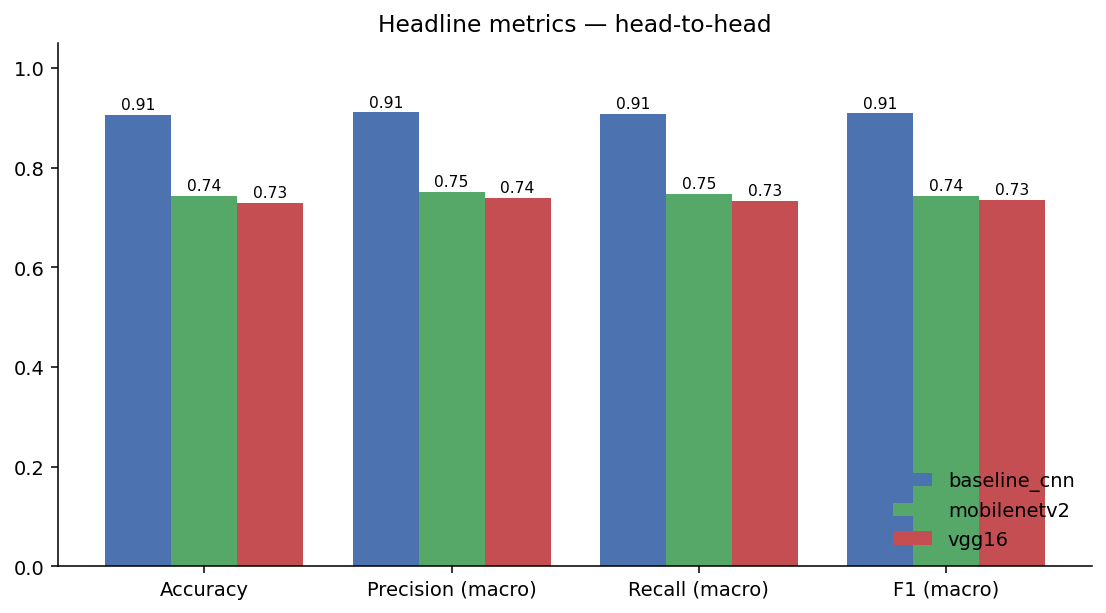

In [6]:
bar_path = plot_headline_metrics_bars(metrics)
print("Saved:", bar_path)
from IPython.display import Image as IPyImage
IPyImage(filename=str(bar_path))


## 5. Per-class F1 bar chart

Saved:

 C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\06_per_class_f1.png


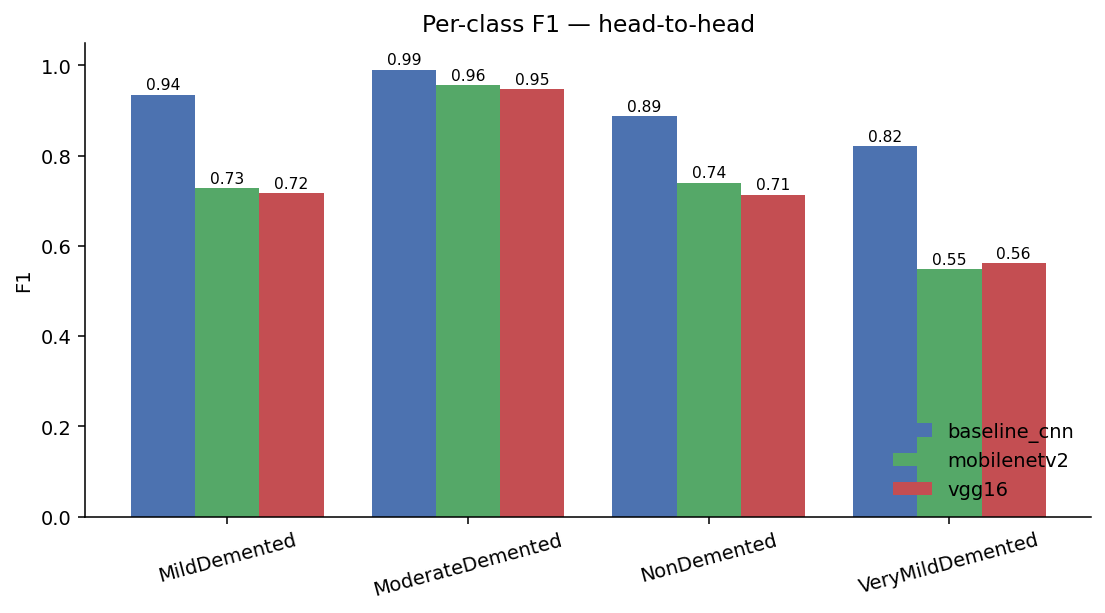

In [7]:
f1_path = plot_per_class_f1_bars(metrics)
print("Saved:", f1_path)
IPyImage(filename=str(f1_path))


## 6. Side-by-side confusion matrices (normalized)

Saved:

 C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\06_confusion_matrices_side_by_side.png


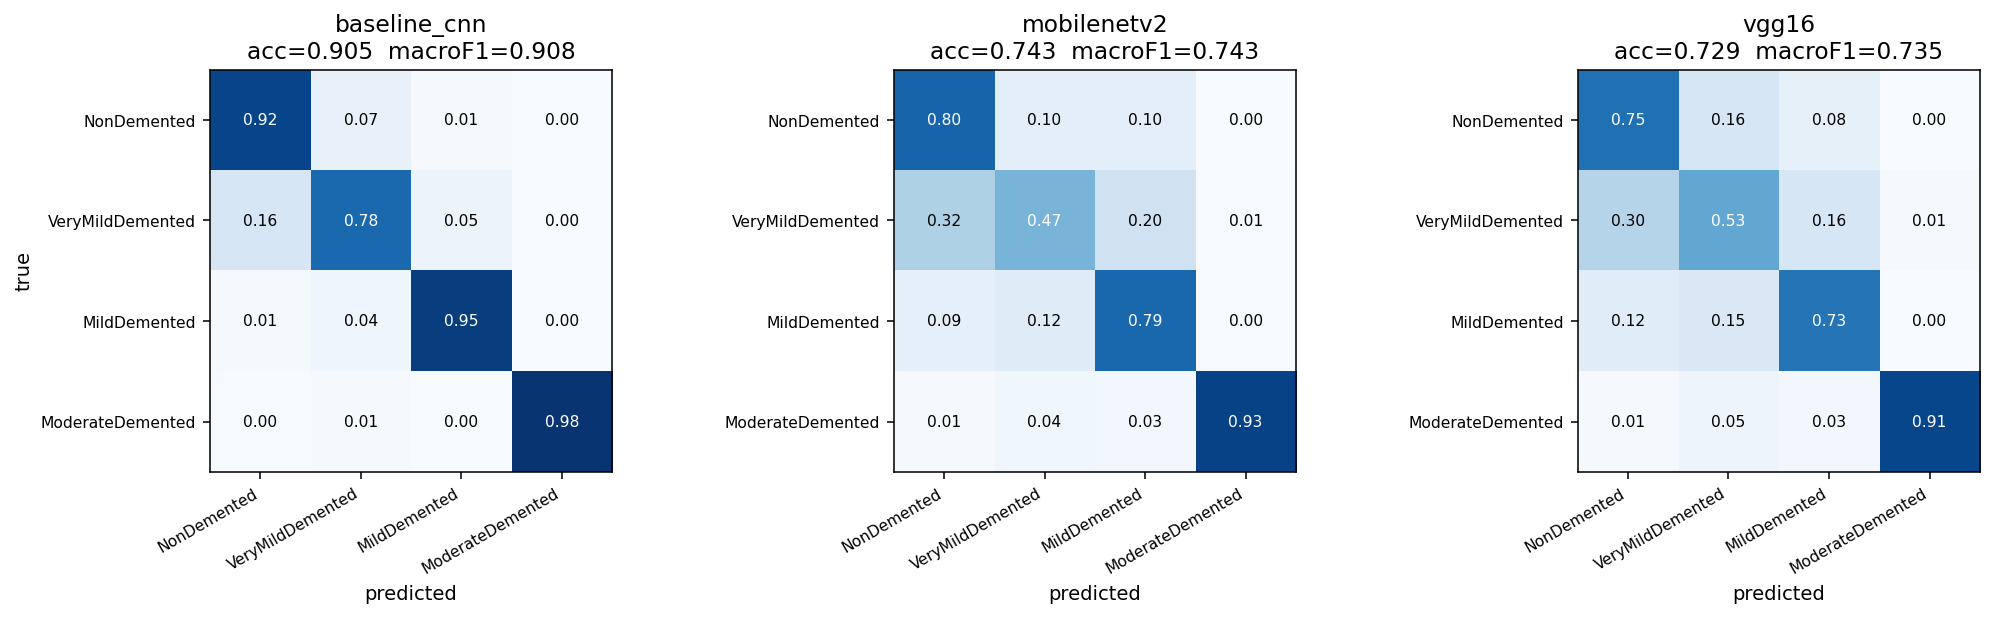

In [8]:
cm_path = plot_confusion_matrices_side_by_side(metrics, normalize=True)
print("Saved:", cm_path)
IPyImage(filename=str(cm_path))


## 7. Observations

With a *full* GPU run for all three models, expect:
- The custom CNN baseline reaches a respectable but lower ceiling than transfer-learning models.
- MobileNetV2 is usually the sweet spot — fastest to train, most stable.
- VGG16 is competitive, but its much larger parameter count typically does NOT translate into a proportional accuracy lift on this dataset.
- The hardest classes are usually the two adjacent severity levels — VeryMildDemented vs MildDemented.

With the smoke-mode CSVs we currently have, the numbers are too noisy to draw real conclusions. Run the three model notebooks on Colab GPU and rerun this notebook to refresh.

## 8. Save Markdown report

In [9]:
report_path = write_comparison_report(metrics)
print("Saved:", report_path)


Saved: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\reports\06_model_comparison.md


## 9. Conclusion for Day 6

Persisted artifacts:
* `outputs/figures/06_metrics_grouped_bars.png`
* `outputs/figures/06_per_class_f1.png`
* `outputs/figures/06_confusion_matrices_side_by_side.png`
* `outputs/reports/06_model_comparison.md`

Next: **07_grad_cam.ipynb** — pick the best model, generate Grad-CAM heatmaps on a few correct and incorrect predictions to see *where* the model is looking.
